# 06 — India Company Analysis

**Chain position:** Macro → Risk → Rates → Global Equity → India → `Companies`

The last link. All 50 Nifty constituents are screened on two legs weighted **50/50**,
ranked, and the top 8 selected with sector diversification enforced.

### The fundamental leg — computed, not looked up

Every ratio here is calculated from the income statement, balance sheet and cash-flow
statement. This is not stylistic preference; `.info` was tested and found unreliable:

- `returnOnEquity` comes back as **`None`** for RELIANCE.NS
- `enterpriseToEbitda` comes back as **982** for INFY.NS

Worse, and only visible once ratios are computed and sanity-checked: Yahoo serves
**INFY.NS statements in USD while quoting its share price in INR.** Dividing one by the
other produced a PE of 1317 and a PB of 447 against real values near 14 and 4.8. The
library detects the mismatch from the shape of the result rather than trusting the
`financialCurrency` field — which is itself wrong for HCLTECH.NS, where it claims USD
but the statements are in INR.

Every metric therefore carries a **provenance tag** (`computed`, `info-fallback`,
`n/a-sector`, `unavailable`), the distribution is printed below, and the run asserts that
no scorecard metric arrived without one.

### The technical leg — swing/positional

Daily bars: 20/50/200 DMA structure, RSI(14), ATR(14), 52-week range position, relative
strength versus the Nifty, and volume trend.

### On what this is

Scores and ATR-derived levels are quantitative outputs, not advice. The level analysis is
the arithmetic a swing trader would do by hand — recent structure for the reference
points, ATR for the distances. The decisions remain yours.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, cache, fetch, align, dashboard,
                 indicators as ind, fundamentals as fnd, score, viz)

# Set REFRESH = True to force a live re-fetch of every source, ignoring the cache.
REFRESH = False
mkt.bootstrap(refresh=REFRESH)

mkt v1.0.0 | run 2026-09-09 10:48 | REFRESH=False | cache=G:\stock market analysis\data\cache


## 1. Resolve the universe

Any ticker that fails is reported and dropped explicitly. The Nifty 50 is not a static
list — Tata Motors demerged, and the old `TATAMOTORS.NS` ticker no longer resolves on
Yahoo, so `config.NIFTY_50` carries `TMPV.NS` instead.

In [2]:
universe = dict(config.NIFTY_50)
print(f"Configured universe: {len(universe)} names across "
      f"{len(set(universe.values()))} sectors\n")

px_frames, px_failed = fetch.price_histories(
    list(universe), period=config.PRICE_HISTORY_PERIOD)

dropped = []
for t, why in px_failed:
    dropped.append({"ticker": t, "sector": universe[t], "stage": "price history", "reason": why})

resolved = [t for t in universe if t in px_frames]
print(f"\nResolved: {len(resolved)}/{len(universe)}")
if dropped:
    print("Dropped (reported, not silently skipped):")
    display(pd.DataFrame(dropped))

Configured universe: 50 names across 15 sectors



  fetched 50/50 tickers in 2s

Resolved: 50/50


In [3]:
bench = fetch.price_history(config.BENCHMARK, period=config.PRICE_HISTORY_PERIOD)["Close"]
print(f"Benchmark {config.BENCHMARK}: {len(bench)} sessions, "
      f"as of {bench.last_valid_index().date()}")

tech_rows = {}
for t in resolved:
    df = px_frames[t]
    if len(df) < 60:
        dropped.append({"ticker": t, "sector": universe[t],
                        "stage": "technicals", "reason": f"only {len(df)} sessions"})
        continue
    snap = ind.technical_snapshot(df, bench)
    snap["last_close"] = float(df["Close"].dropna().iloc[-1])
    snap["as_of"] = df["Close"].last_valid_index().date()
    tech_rows[t] = snap

tech = pd.DataFrame(tech_rows).T
tech["sector"] = [universe[t] for t in tech.index]
print(f"Technical snapshot built for {len(tech)} names")
display(tech[["last_close", "as_of", "RSI14", "ATR14_%", "px_vs_DMA200_%",
              "pos_52w_%", "rs_63d_pp", "ret_12m_%"]].head(10).round(2))

Benchmark ^NSEI: 739 sessions, as of 2026-09-09


Technical snapshot built for 50 names


,last_close,as_of,RSI14,ATR14_%,px_vs_DMA200_%,pos_52w_%,rs_63d_pp,ret_12m_%
ADANIENT.NS,"3,116.30",2026-09-09,58.77,2.69,23.59,93.41,4.92,34.81
ADANIPORTS.NS,"1,754.90",2026-09-09,58.19,2.15,8.97,77.86,-5.04,27.08
APOLLOHOSP.NS,"8,901.00",2026-09-09,55.15,1.77,12.58,93.40,3.15,13.74
ASIANPAINT.NS,"2,468.80",2026-09-09,26.40,2.04,-4.93,41.02,-10.47,-2.70
AXISBANK.NS,"1,248.10",2026-09-09,47.69,1.86,-3.15,55.84,-6.45,18.62
BAJAJ-AUTO.NS,"11,858.00",2026-09-09,54.75,1.80,17.95,86.53,15.61,26.38
BAJFINANCE.NS,"1,048.70",2026-09-09,41.82,1.92,7.30,69.18,18.84,10.58
BAJAJFINSV.NS,"1,937.40",2026-09-09,40.30,1.78,1.85,56.09,16.14,-4.34
BEL.NS,407.95,2026-09-09,50.14,1.70,-2.64,37.31,-0.22,9.68
BHARTIARTL.NS,"1,824.50",2026-09-09,38.27,1.86,-5.44,16.68,0.72,-3.65


## 2. Fundamentals

Five years of annual statements plus quarterlies for every name. This is the expensive
call — roughly 75 seconds cold — so it is cached; re-runs are near-instant unless
`REFRESH = True`.

In [4]:
bundles, fund_failed = fetch.fundamentals_many(list(tech.index))
for t, why in fund_failed:
    dropped.append({"ticker": t, "sector": universe[t],
                    "stage": "fundamentals", "reason": why})

fund_rows, provs = {}, {}
for t, b in bundles.items():
    price = float(tech.loc[t, "last_close"])
    m, p = fnd.compute_ratios(b, t, universe[t], price=price)
    fund_rows[t] = m
    provs[t] = p

fund = pd.DataFrame(fund_rows).T
print(f"Fundamental ratios computed for {len(fund)} names")

flagged = fund[fund["data_flags"].astype(str).str.len() > 0]
if len(flagged):
    print(f"\n{len(flagged)} name(s) needed a data correction:")
    for t, f in flagged["data_flags"].items():
        print(f"   {t:14s} {f}")

  fundamentals: 50/50 in 1s


Fundamental ratios computed for 50 names

3 name(s) needed a data correction:
   ETERNAL.NS     PE=750.0 out of bounds
   INFY.NS        market cap converted to statement currency [USD/INR=95.15]
   JIOFIN.NS      revenue_cagr_%=431.7 out of bounds; fcf_margin_%=-488.0 out of bounds


### Trap #2 — provenance

The proof that these ratios came from the statements. `computed` means calculated from
the filings; `info-fallback` means the statements lacked an input and `.info` supplied a
plausible one; `n/a-sector` means the metric is meaningless for banks and NBFCs (no
EBITDA, no classical debt/equity); `unavailable` means neither source produced something
credible — deliberately blank rather than confidently wrong.

In [5]:
prov_tbl = fnd.provenance_summary(provs)
display(prov_tbl)

check = fnd.assert_provenance(provs, list(score.FUNDAMENTAL_SPEC))
display(check)

computed_share = prov_tbl[fnd.COMPUTED].sum() / (
    prov_tbl[[fnd.COMPUTED, fnd.INFO, fnd.MISSING]].sum().sum()) * 100
print(f"{computed_share:.1f}% of all non-sector-excluded metrics were computed from "
      f"the statements rather than taken from .info")

,metric,computed,info-fallback,n/a-sector,unavailable,coverage_%
3,PEG,44,0,0,6,88.00
7,cash_conversion,48,0,0,2,96.00
2,PE,49,0,0,1,98.00
11,earn_yoy_q_%,49,0,0,1,98.00
12,earnings_cagr_%,49,0,0,1,98.00
14,fcf_margin_%,49,0,0,1,98.00
10,div_yield_%,49,0,0,1,98.00
21,revenue_cagr_%,49,0,0,1,98.00
20,rev_yoy_q_%,49,0,0,1,98.00
5,ROCE_%,38,0,12,0,100.00


,tickers_checked,metrics_checked,result
0,50,16,all metrics carry a known provenance


96.7% of all non-sector-excluded metrics were computed from the statements rather than taken from .info


## 3. Valuation against sector peers

An absolute PE says little across sectors — IT and utilities are not comparable. Each
name is therefore also expressed relative to its **own sector's median**.

Sector median valuations:


,PE,PB,EV_EBITDA,PEG,div_yield_%
sector,,,,,
Automobile,23.37,4.44,13.85,1.17,1.42
Capital Goods,51.16,12.43,34.40,1.92,0.70
Construction,33.77,5.03,19.90,2.20,0.85
Construction Materials,34.05,3.19,18.74,1.96,0.72
Consumer Durables,63.46,19.63,42.96,16.64,0.62
Consumer Services,83.07,15.51,77.63,1.46,0.12
FMCG,47.14,7.00,31.57,4.93,1.56
Financial Services,25.43,2.51,NaN,1.22,0.56
Healthcare,36.72,4.30,20.79,2.92,0.79


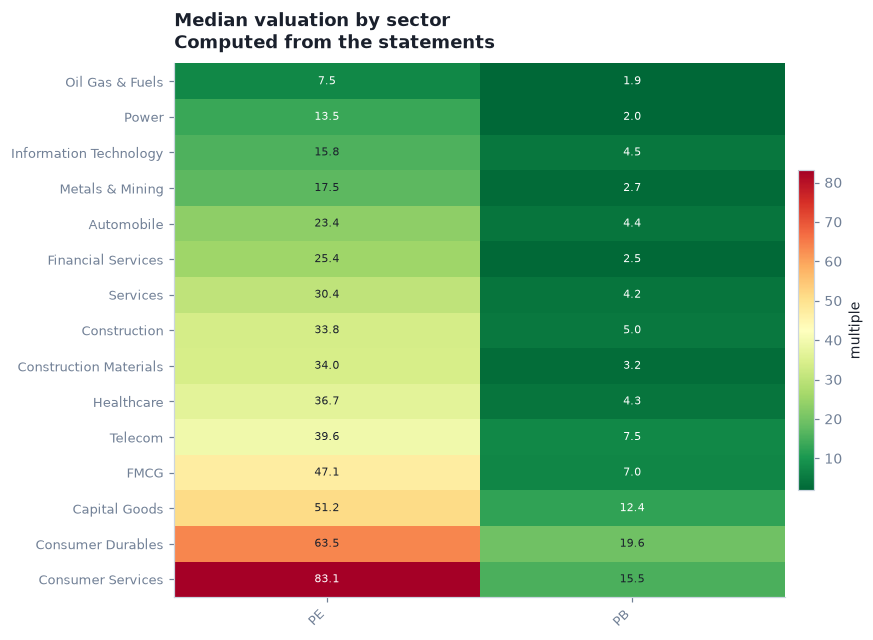

In [6]:
val_cols = ["PE", "PB", "EV_EBITDA", "PEG", "div_yield_%"]
val = fund[val_cols + ["sector"]].copy()
for c in val_cols:
    val[c] = pd.to_numeric(val[c], errors="coerce")

sector_med = val.groupby("sector")[val_cols].median()
for c in ["PE", "PB", "EV_EBITDA"]:
    val[f"{c}_vs_sector_%"] = val.apply(
        lambda r: (r[c] / sector_med.loc[r["sector"], c] - 1) * 100
        if np.isfinite(r[c]) and np.isfinite(sector_med.loc[r["sector"], c])
        and sector_med.loc[r["sector"], c] != 0 else np.nan, axis=1)

print("Sector median valuations:")
display(sector_med.round(2))

heat = sector_med[["PE", "PB"]].dropna(how="all").sort_values("PE")
fig, ax = plt.subplots(figsize=(7.5, max(4, 0.42 * len(heat))))
viz.heatmap(heat, ax=ax, cmap="RdYlGn_r", fmt="{:.1f}",
            title_="Median valuation by sector", sub="Computed from the statements",
            cbar_label="multiple")
viz.save(fig, "06_sector_valuation"); plt.show()

## 4. The scorecard

Two blocks scored independently with robust (median/MAD) z-scores, so one 120x PE cannot
flatten everyone else's valuation score. Each block is converted to a 0-100 percentile,
then combined **50% fundamental / 50% technical**.

Missing inputs are scored neutral and the per-name coverage is reported, so a thinly
covered score can be discounted rather than trusted blindly.

In [7]:
common = [t for t in fund.index if t in tech.index]
combined = fund.loc[common].join(tech.loc[common], rsuffix="_t")
combined["sector"] = [universe[t] for t in combined.index]
for c in list(score.FUNDAMENTAL_SPEC) + list(score.TECHNICAL_SPEC):
    if c in combined.columns:
        combined[c] = pd.to_numeric(combined[c], errors="coerce")

f_score, f_contrib = score.score_block(combined, score.FUNDAMENTAL_SPEC, "fundamental")
t_score, t_contrib = score.score_block(combined, score.TECHNICAL_SPEC, "technical")

board = score.composite(f_score, t_score)
board["sector"] = combined["sector"]
board["fund_coverage_%"] = f_contrib["_coverage_%"]
board["tech_coverage_%"] = t_contrib["_coverage_%"]
board = board.sort_values("composite", ascending=False)
board["rank"] = range(1, len(board) + 1)

assert np.isfinite(board["composite"]).all(), "composite score produced a non-finite value"
assert board["composite"].between(0, 100).all(), "composite outside 0-100"
print(f"Scored {len(board)} names. Composite range "
      f"{board['composite'].min():.1f} to {board['composite'].max():.1f}; all finite.")
display(board.head(15).round(1))

Scored 50 names. Composite range 13.0 to 89.0; all finite.


,fund_score,tech_score,fund_pct,tech_pct,composite,sector,fund_coverage_%,tech_coverage_%,rank
BAJAJ-AUTO.NS,6.50,16.90,82.00,96.00,89.00,Automobile,100.00,100.00,1
KOTAKBANK.NS,5.60,10.10,80.00,88.00,84.00,Financial Services,76.00,100.00,2
COALINDIA.NS,7.00,7.70,86.00,78.00,82.00,Oil Gas & Fuels,100.00,100.00,3
ADANIPORTS.NS,5.50,9.80,78.00,86.00,82.00,Services,100.00,100.00,4
ICICIBANK.NS,6.80,5.80,84.00,72.00,78.00,Financial Services,76.00,100.00,5
JSWSTEEL.NS,4.90,8.90,74.00,82.00,78.00,Metals & Mining,100.00,100.00,6
TITAN.NS,2.40,16.90,56.00,98.00,77.00,Consumer Durables,100.00,100.00,7
EICHERMOT.NS,7.40,5.20,88.00,64.00,76.00,Automobile,100.00,100.00,8
HEROMOTOCO.NS,10.00,-0.60,98.00,50.00,74.00,Automobile,100.00,100.00,9
BAJFINANCE.NS,2.60,9.00,60.00,84.00,72.00,Financial Services,76.00,100.00,10


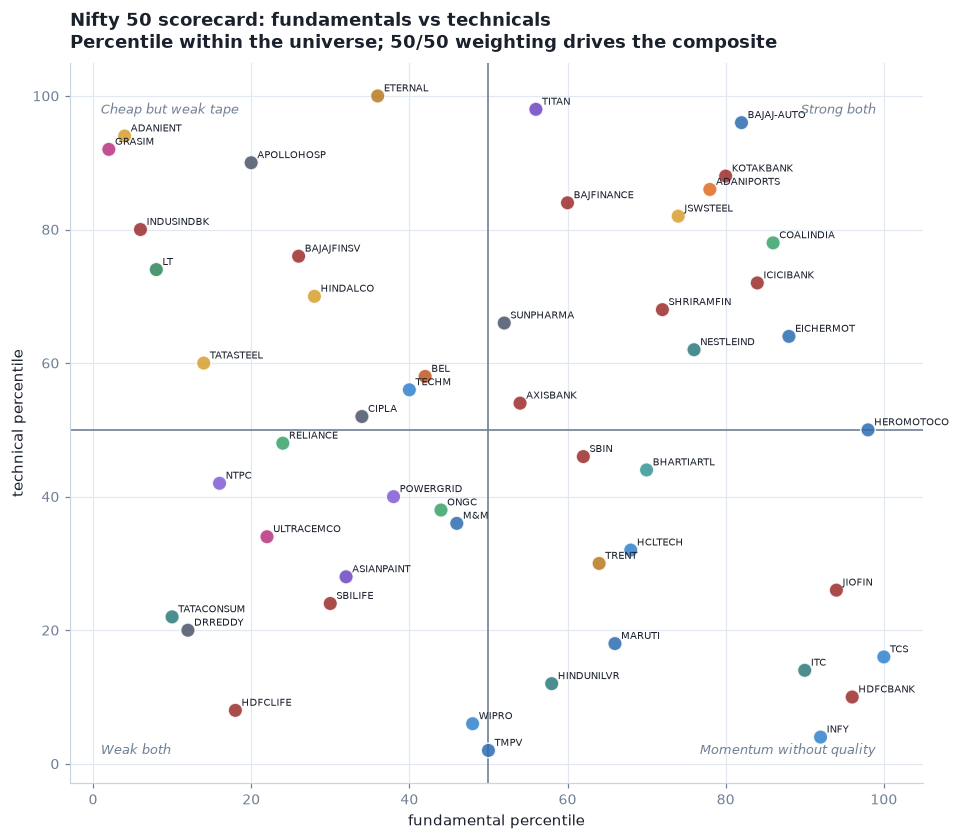

In [8]:
fig, ax = plt.subplots(figsize=(10, 8.5))
colors = {s: viz.PALETTE[i % len(viz.PALETTE)]
          for i, s in enumerate(sorted(board["sector"].unique()))}
ax.scatter(board["fund_pct"], board["tech_pct"],
           s=90, c=[colors[s] for s in board["sector"]],
           alpha=0.85, edgecolor="white", zorder=3)
for t, r in board.iterrows():
    ax.annotate(t.replace(".NS", ""), (r["fund_pct"], r["tech_pct"]),
                fontsize=6.8, xytext=(4, 3), textcoords="offset points")
ax.axvline(50, color=viz.MUTED, lw=1.1); ax.axhline(50, color=viz.MUTED, lw=1.1)
for txt, xy, ha, va in [("Strong both", (99, 99), "right", "top"),
                        ("Cheap but weak tape", (1, 99), "left", "top"),
                        ("Weak both", (1, 1), "left", "bottom"),
                        ("Momentum without quality", (99, 1), "right", "bottom")]:
    ax.text(*xy, txt, fontsize=8.5, color=viz.MUTED, style="italic", ha=ha, va=va)
viz.title(ax, "Nifty 50 scorecard: fundamentals vs technicals",
          "Percentile within the universe; 50/50 weighting drives the composite")
ax.set_xlabel("fundamental percentile"); ax.set_ylabel("technical percentile")
viz.save(fig, "06_scorecard_scatter"); plt.show()

## 5. Export the full screen

All names, every input, written to `outputs/nifty50_screen.csv`.

In [9]:
export = board.join(
    combined[[c for c in ["ROE_%", "ROCE_%", "op_margin_%", "net_margin_%",
                          "revenue_cagr_%", "earnings_cagr_%", "rev_yoy_q_%",
                          "earn_yoy_q_%", "debt_to_equity", "interest_coverage",
                          "fcf_margin_%", "cash_conversion", "PE", "PB", "EV_EBITDA",
                          "PEG", "div_yield_%", "market_cap", "last_close",
                          "RSI14", "ATR14_%", "px_vs_DMA20_%", "px_vs_DMA50_%",
                          "px_vs_DMA200_%", "n_dma_above", "pos_52w_%",
                          "ret_3m_%", "ret_6m_%", "ret_12m_%", "rs_63d_pp",
                          "rs_126d_pp", "vol_ann_%", "dd_from_high_%",
                          "statement_asof", "data_flags"] if c in combined.columns]])
export = export.join(val[[c for c in val.columns if c.endswith("_vs_sector_%")]])
export.index.name = "ticker"

path = config.OUTPUT_DIR / "nifty50_screen.csv"
export.round(4).to_csv(path)
print(f"Wrote {path}  ({export.shape[0]} rows x {export.shape[1]} columns)")

if dropped:
    dpath = config.OUTPUT_DIR / "nifty50_dropped.csv"
    pd.DataFrame(dropped).to_csv(dpath, index=False)
    print(f"Wrote {dpath}  ({len(dropped)} dropped ticker(s))")
print(f"\nScreen covers {len(export)} of {len(universe)} configured names.")

Wrote G:\stock market analysis\outputs\nifty50_screen.csv  (50 rows x 47 columns)

Screen covers 50 of 50 configured names.


## 6. Top 8, with sector diversification enforced

A pure ranking can hand back eight financials — a concentrated sector bet dressed up as a
diversified screen. The selection caps each sector at
`config.MAX_PER_SECTOR` names and flags any slot where the cap had to be relaxed.

In [10]:
top = score.select_diversified(board, n=config.TOP_N_DEEP_DIVE,
                               max_per_sector=config.MAX_PER_SECTOR)
display(top[["rank", "sector", "composite", "fund_pct", "tech_pct",
             "fund_coverage_%", "tech_coverage_%", "sector_cap_relaxed"]].round(1))

naive_top = board.head(config.TOP_N_DEEP_DIVE)
print(f"Sectors in the diversified top {config.TOP_N_DEEP_DIVE}: "
      f"{top['sector'].nunique()}  {sorted(top['sector'].unique())}")
print(f"Sectors in an uncapped top {config.TOP_N_DEEP_DIVE}: "
      f"{naive_top['sector'].nunique()}  {sorted(naive_top['sector'].unique())}")
swapped = [t for t in top.index if t not in naive_top.index]
if swapped:
    print(f"The cap changed the selection: {swapped} entered in place of "
          f"{[t for t in naive_top.index if t not in top.index]}")
else:
    print("The cap did not bind -- the raw ranking was already diversified.")

,rank,sector,composite,fund_pct,tech_pct,fund_coverage_%,tech_coverage_%,sector_cap_relaxed
ticker,,,,,,,,
BAJAJ-AUTO.NS,1,Automobile,89.00,82.00,96.00,100.00,100.00,False
KOTAKBANK.NS,2,Financial Services,84.00,80.00,88.00,76.00,100.00,False
COALINDIA.NS,3,Oil Gas & Fuels,82.00,86.00,78.00,100.00,100.00,False
ADANIPORTS.NS,4,Services,82.00,78.00,86.00,100.00,100.00,False
ICICIBANK.NS,5,Financial Services,78.00,84.00,72.00,76.00,100.00,False
JSWSTEEL.NS,6,Metals & Mining,78.00,74.00,82.00,100.00,100.00,False
TITAN.NS,7,Consumer Durables,77.00,56.00,98.00,100.00,100.00,False
EICHERMOT.NS,8,Automobile,76.00,88.00,64.00,100.00,100.00,False


Sectors in the diversified top 8: 6  ['Automobile', 'Consumer Durables', 'Financial Services', 'Metals & Mining', 'Oil Gas & Fuels', 'Services']
Sectors in an uncapped top 8: 6  ['Automobile', 'Consumer Durables', 'Financial Services', 'Metals & Mining', 'Oil Gas & Fuels', 'Services']
The cap did not bind -- the raw ranking was already diversified.


## 7. Deep dives

For each selected name: the fundamental record, the statement trend, an annotated price
chart, and ATR-derived level analysis.

**On the levels:** `support`/`resistance` are ATR multiples from the current close;
`stop` and `target` are the 2-ATR and 3-ATR distances a swing trader would size against;
`swing high/low` are the actual 60-session extremes. They describe structure and
volatility — they are not predictions.

BAJAJ-AUTO  |  Automobile  |  rank 1 of 50  |  composite 89.0
   fundamental percentile 82 (coverage 100%)   technical percentile 96 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,29.03,25.93,computed,3.10
ROCE_%,32.60,24.07,computed,8.54
op_margin_%,25.04,16.93,computed,8.11
net_margin_%,17.79,15.00,computed,2.79
revenue_cagr_%,19.49,16.68,computed,2.81
earnings_cagr_%,21.03,22.40,computed,-1.37
rev_yoy_q_%,65.03,33.07,computed,31.96
earn_yoy_q_%,45.93,4.74,computed,41.19
debt_to_equity,0.58,0.31,computed,0.27
interest_coverage,12.95,47.02,computed,-34.07


,value
last_close,"11,858.00"
RSI14,54.75
ATR14_%,1.80
px_vs_DMA20_%,0.13
px_vs_DMA50_%,5.20
px_vs_DMA200_%,17.95
n_dma_above,3
stack_bullish,True
pos_52w_%,86.53
ret_3m_%,16.90


,level,% from close,ATR multiples
60d swing high,"12,470.00",5.16,2.87
+2 ATR,"12,284.00",3.59,2.00
+1 ATR,"12,071.00",1.80,1.00
close,"11,858.00",0.00,0.00
-1 ATR,"11,645.00",-1.80,-1.00
-2 ATR (stop),"11,432.00",-3.59,-2.00
60d swing low,"9,501.00",-19.88,-11.07
+3 ATR (target),"12,497.00",5.39,3.00


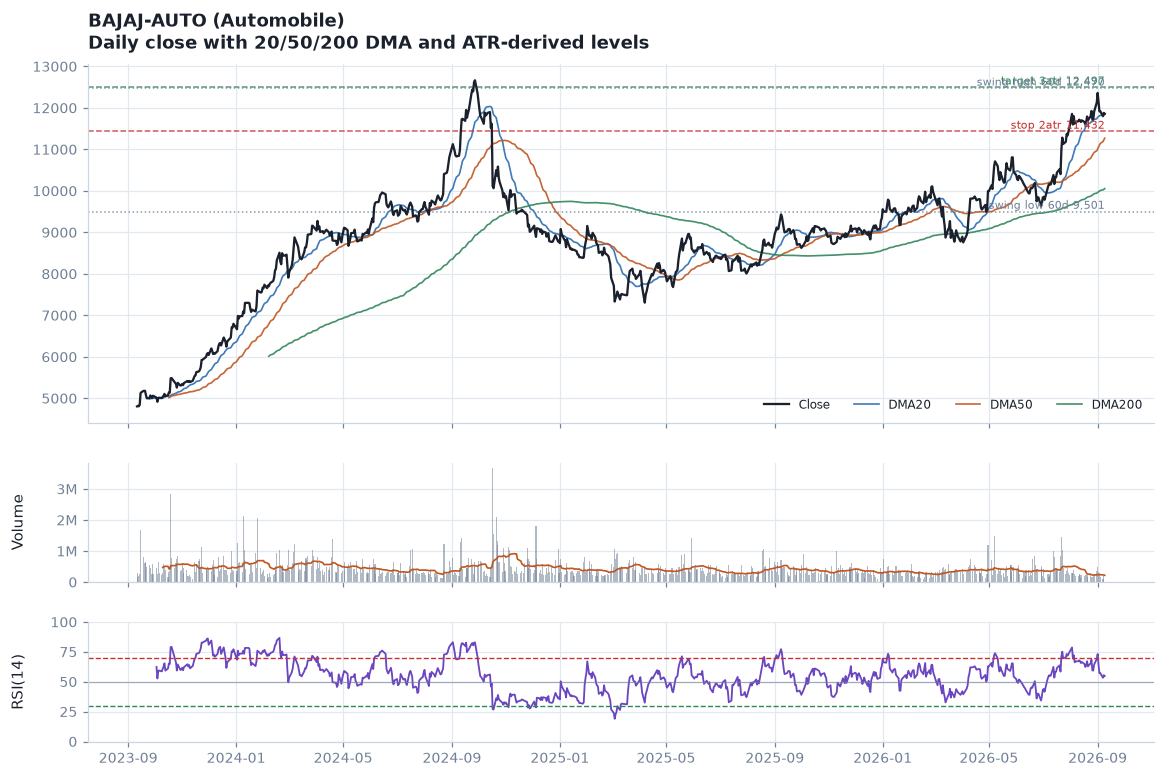

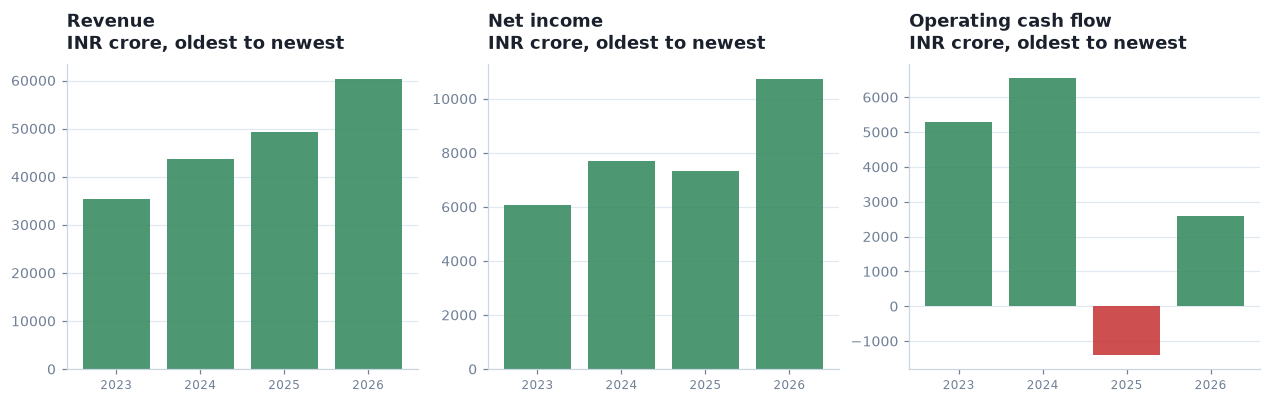


KOTAKBANK  |  Financial Services  |  rank 2 of 50  |  composite 84.0
   fundamental percentile 80 (coverage 76%)   technical percentile 88 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,11.39,13.08,computed,-1.69
ROCE_%,NaN,NaN,n/a-sector,NaN
op_margin_%,34.76,37.11,info-fallback,-2.35
net_margin_%,25.45,24.86,computed,0.59
revenue_cagr_%,13.48,13.48,computed,0.00
earnings_cagr_%,9.02,14.78,computed,-5.75
rev_yoy_q_%,11.42,21.93,computed,-10.51
earn_yoy_q_%,11.10,13.88,computed,-2.78
debt_to_equity,NaN,NaN,n/a-sector,NaN
interest_coverage,NaN,NaN,n/a-sector,NaN


,value
last_close,414.85
RSI14,56.82
ATR14_%,1.72
px_vs_DMA20_%,1.64
px_vs_DMA50_%,4.87
px_vs_DMA200_%,3.57
n_dma_above,3
stack_bullish,False
pos_52w_%,67.00
ret_3m_%,6.89


,level,% from close,ATR multiples
60d swing high,429.10,3.43,1.99
+2 ATR,429.14,3.44,2.00
+1 ATR,421.99,1.72,1.00
close,414.85,0.00,0.00
-1 ATR,407.71,-1.72,-1.00
-2 ATR (stop),400.56,-3.44,-2.00
60d swing low,368.40,-11.20,-6.50
+3 ATR (target),436.28,5.17,3.00


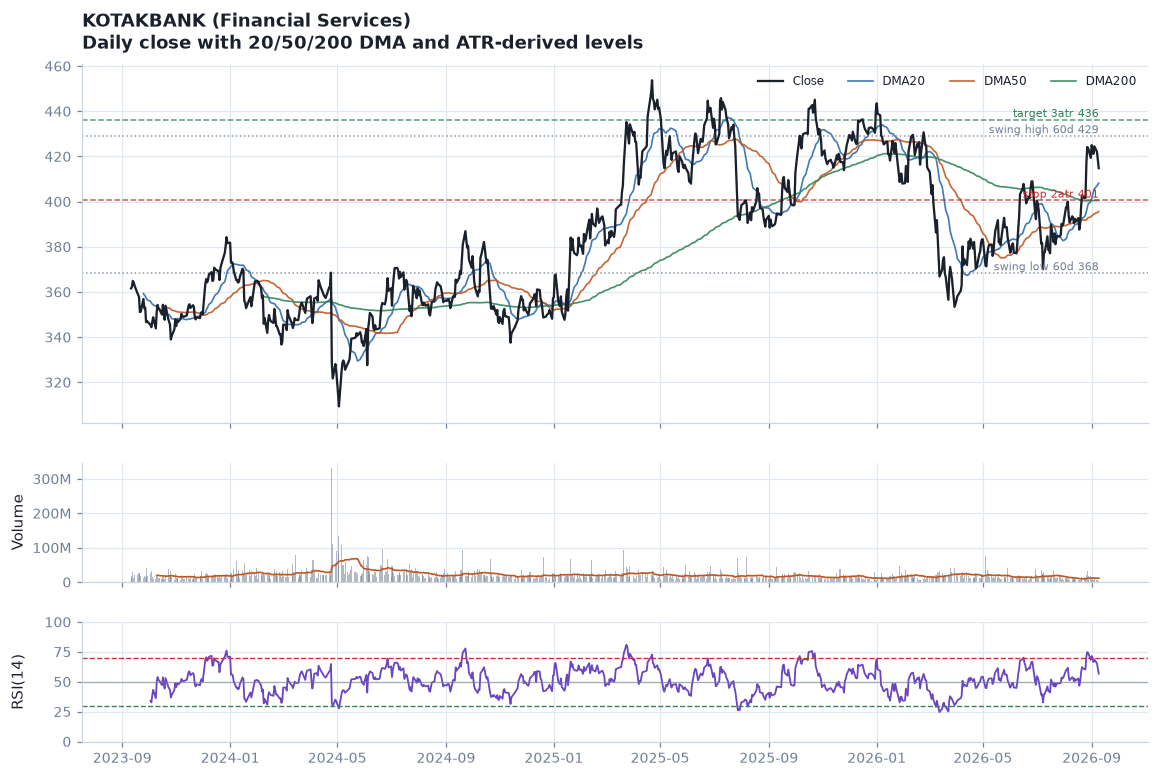

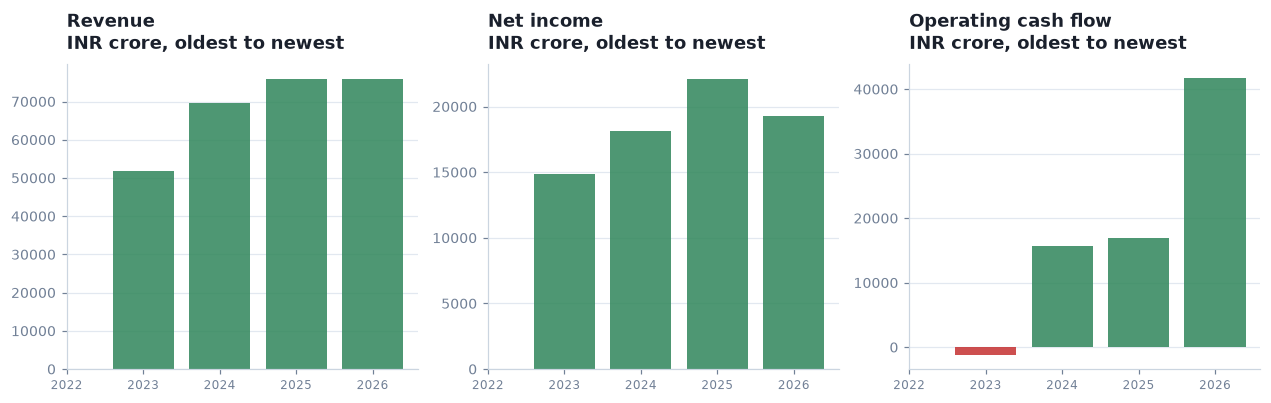


COALINDIA  |  Oil Gas & Fuels  |  rank 3 of 50  |  composite 82.0
   fundamental percentile 86 (coverage 100%)   technical percentile 78 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,28.16,11.58,computed,16.58
ROCE_%,20.88,12.92,computed,7.96
op_margin_%,25.71,13.93,computed,11.78
net_margin_%,18.68,7.64,computed,11.04
revenue_cagr_%,9.31,6.39,computed,2.91
earnings_cagr_%,-0.71,4.11,computed,-4.82
rev_yoy_q_%,5.22,18.39,computed,-13.18
earn_yoy_q_%,-9.22,7.93,computed,-17.15
debt_to_equity,0.12,0.44,computed,-0.32
interest_coverage,49.88,7.31,computed,42.57


,value
last_close,434.00
RSI14,69.39
ATR14_%,1.88
px_vs_DMA20_%,6.04
px_vs_DMA50_%,3.87
px_vs_DMA200_%,0.78
n_dma_above,3
stack_bullish,False
pos_52w_%,57.30
ret_3m_%,-3.77


,level,% from close,ATR multiples
60d swing high,457.50,5.41,2.88
+2 ATR,450.32,3.76,2.00
+1 ATR,442.16,1.88,1.00
close,434.00,0.00,0.00
-1 ATR,425.84,-1.88,-1.00
-2 ATR (stop),417.68,-3.76,-2.00
60d swing low,395.80,-8.80,-4.68
+3 ATR (target),458.47,5.64,3.00


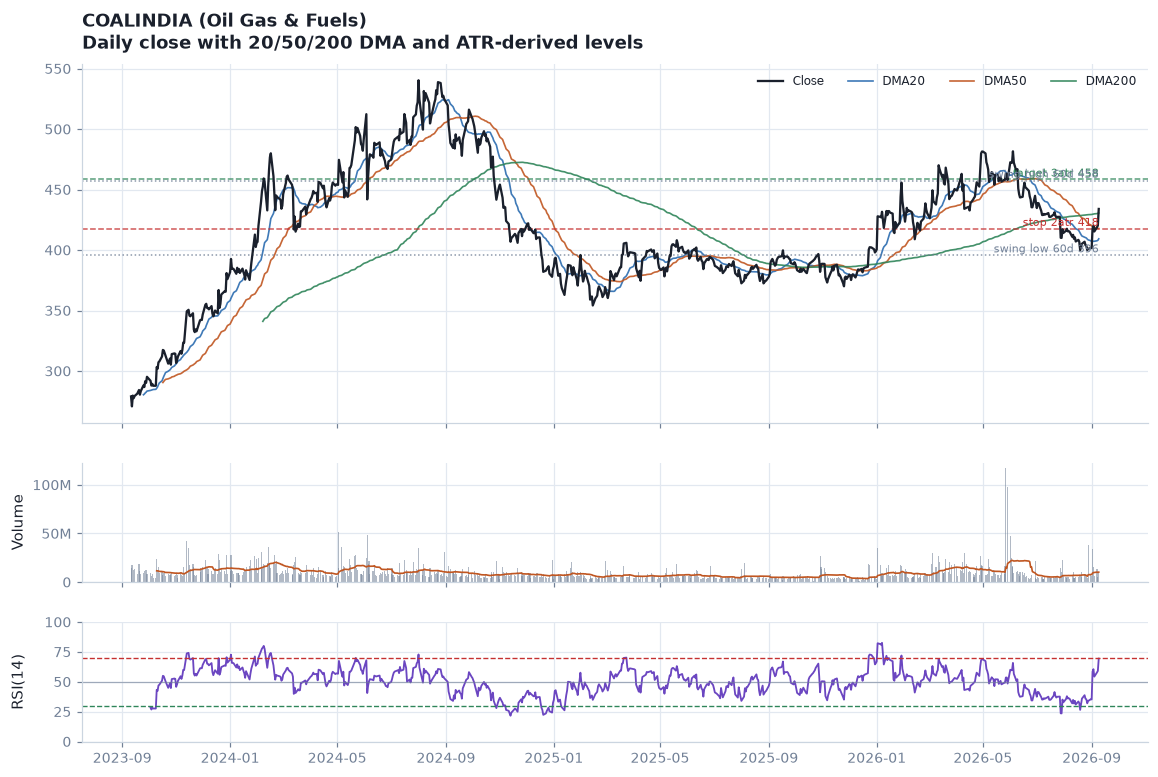

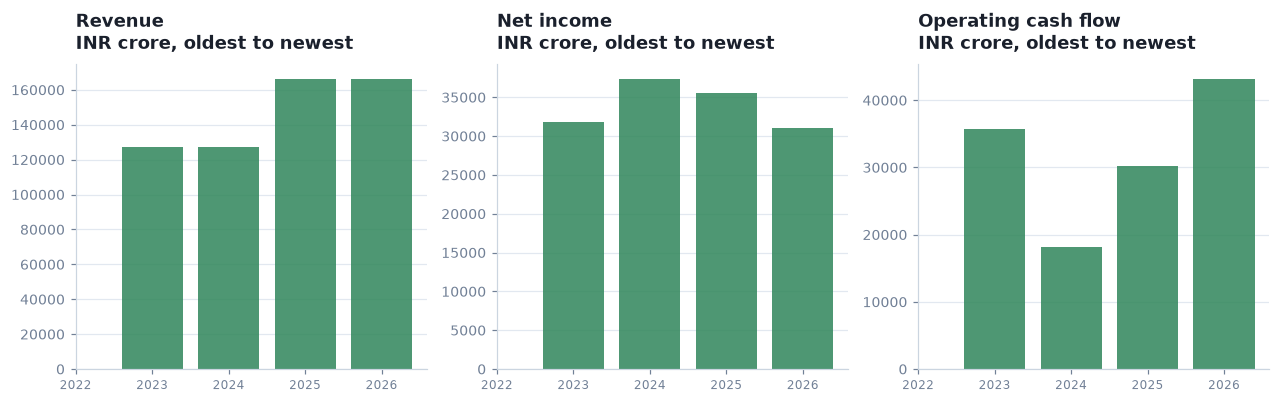


ADANIPORTS  |  Services  |  rank 4 of 50  |  composite 82.0
   fundamental percentile 78 (coverage 100%)   technical percentile 86 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,16.15,16.15,computed,0.00
ROCE_%,12.87,12.87,computed,0.00
op_margin_%,48.02,48.02,computed,0.00
net_margin_%,33.06,33.06,computed,0.00
revenue_cagr_%,22.93,22.93,computed,0.00
earnings_cagr_%,34.11,34.11,computed,0.00
rev_yoy_q_%,27.48,27.48,computed,0.00
earn_yoy_q_%,20.11,20.11,computed,0.00
debt_to_equity,0.66,0.66,computed,0.00
interest_coverage,4.96,4.96,computed,0.00


,value
last_close,"1,754.90"
RSI14,58.19
ATR14_%,2.15
px_vs_DMA20_%,3.98
px_vs_DMA50_%,0.71
px_vs_DMA200_%,8.97
n_dma_above,3
stack_bullish,False
pos_52w_%,77.86
ret_3m_%,-3.64


,level,% from close,ATR multiples
60d swing high,"1,891.10",7.76,3.60
+2 ATR,"1,830.47",4.31,2.00
+1 ATR,"1,792.68",2.15,1.00
close,"1,754.90",0.00,0.00
-1 ATR,"1,717.12",-2.15,-1.00
-2 ATR (stop),"1,679.33",-4.31,-2.00
60d swing low,"1,593.10",-9.22,-4.28
+3 ATR (target),"1,868.25",6.46,3.00


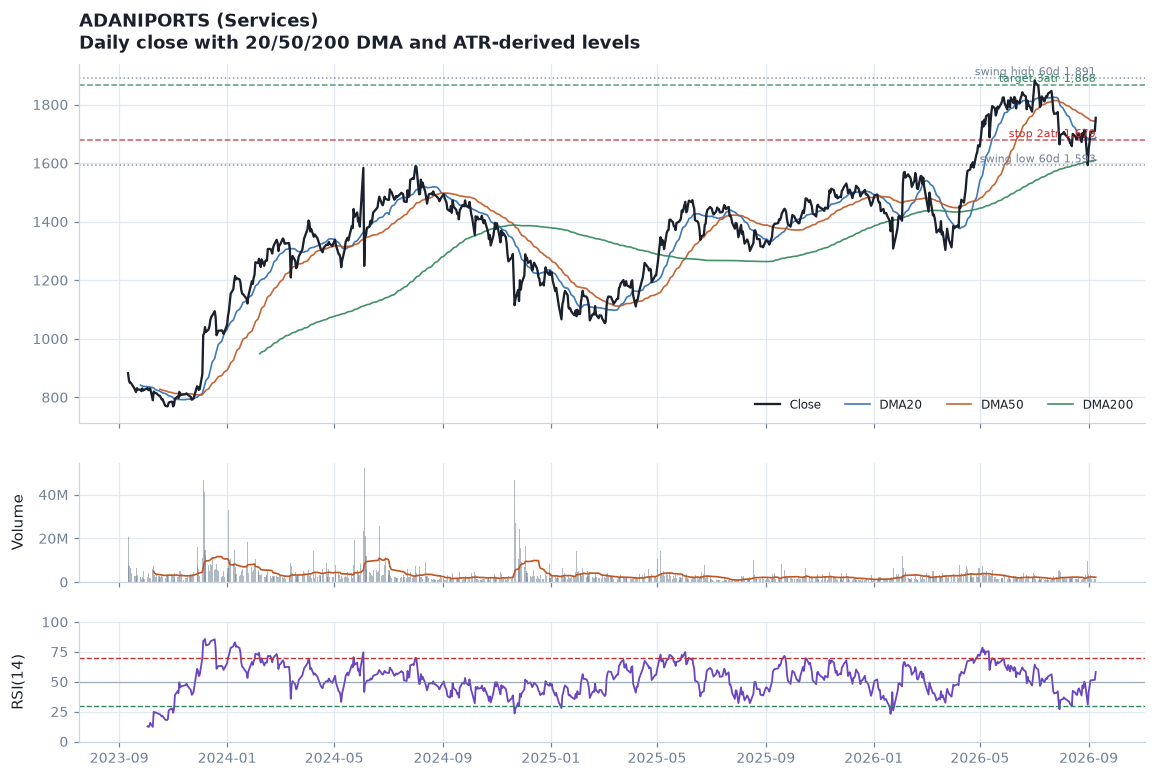

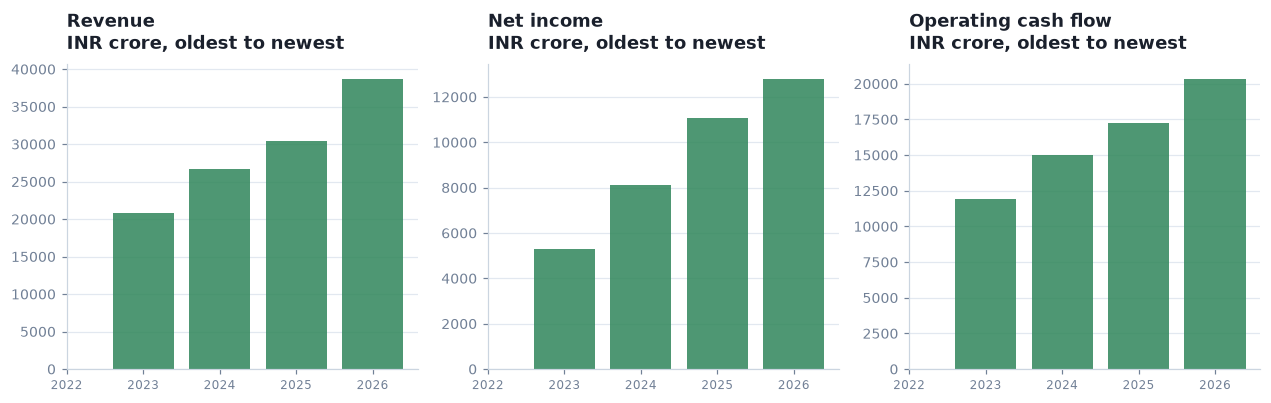


ICICIBANK  |  Financial Services  |  rank 5 of 50  |  composite 78.0
   fundamental percentile 84 (coverage 76%)   technical percentile 72 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,16.01,13.08,computed,2.94
ROCE_%,NaN,NaN,n/a-sector,NaN
op_margin_%,38.51,37.11,info-fallback,1.40
net_margin_%,24.26,24.86,computed,-0.59
revenue_cagr_%,18.11,13.48,computed,4.63
earnings_cagr_%,16.78,14.78,computed,2.00
rev_yoy_q_%,7.73,21.93,computed,-14.20
earn_yoy_q_%,13.88,13.88,computed,0.00
debt_to_equity,NaN,NaN,n/a-sector,NaN
interest_coverage,NaN,NaN,n/a-sector,NaN


,value
last_close,"1,391.20"
RSI14,40.11
ATR14_%,1.53
px_vs_DMA20_%,-2.06
px_vs_DMA50_%,-2.40
px_vs_DMA200_%,2.59
n_dma_above,1
stack_bullish,False
pos_52w_%,72.05
ret_3m_%,7.57


,level,% from close,ATR multiples
60d swing high,"1,480.00",6.38,4.18
+2 ATR,"1,433.71",3.06,2.00
+1 ATR,"1,412.45",1.53,1.00
close,"1,391.20",0.00,0.00
-1 ATR,"1,369.95",-1.53,-1.00
-2 ATR (stop),"1,348.69",-3.06,-2.00
60d swing low,"1,331.40",-4.30,-2.81
+3 ATR (target),"1,454.96",4.58,3.00


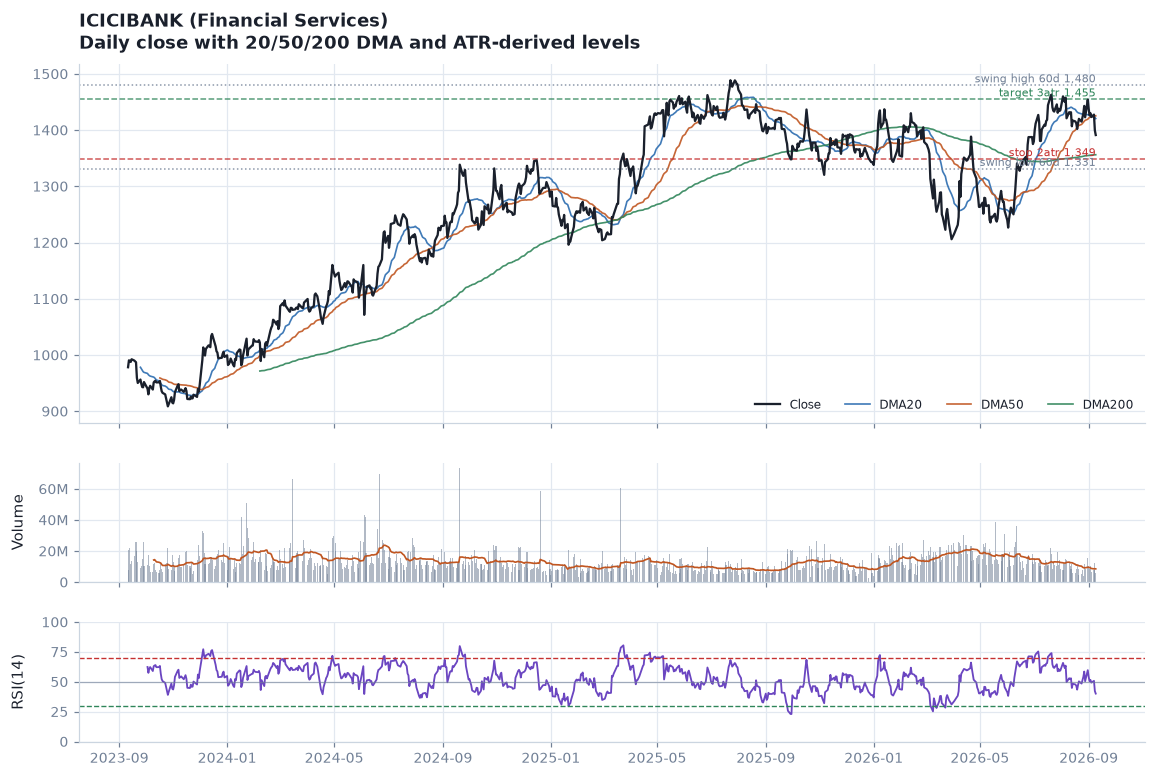

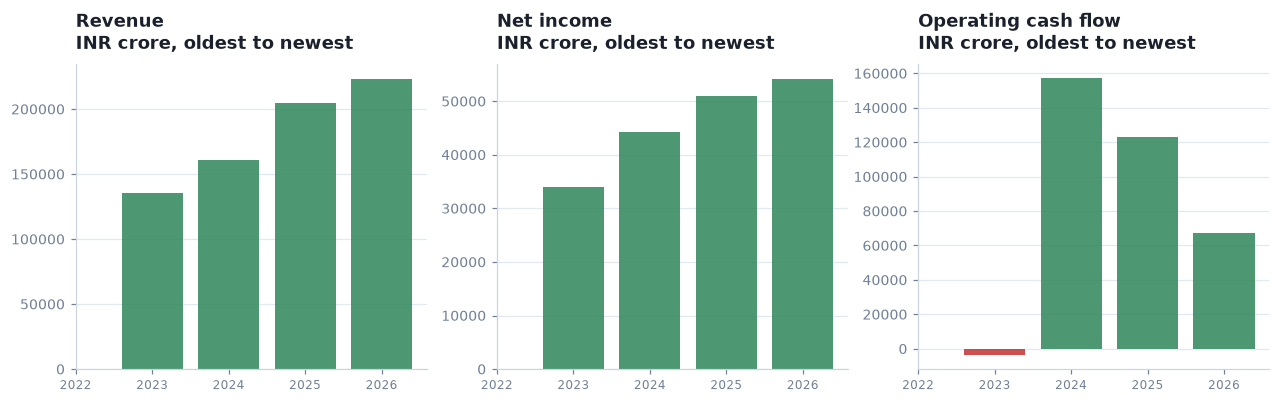


JSWSTEEL  |  Metals & Mining  |  rank 6 of 50  |  composite 78.0
   fundamental percentile 74 (coverage 100%)   technical percentile 82 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,24.86,12.62,computed,12.24
ROCE_%,20.21,11.81,computed,8.40
op_margin_%,20.63,14.96,computed,5.67
net_margin_%,12.26,7.06,computed,5.20
revenue_cagr_%,3.61,1.01,computed,2.60
earnings_cagr_%,75.28,32.59,computed,42.69
rev_yoy_q_%,5.23,18.32,computed,-13.08
earn_yoy_q_%,209.45,43.37,computed,166.08
debt_to_equity,1.19,1.05,computed,0.14
interest_coverage,4.52,3.88,computed,0.65


,value
last_close,"1,304.50"
RSI14,51.51
ATR14_%,1.89
px_vs_DMA20_%,-0.02
px_vs_DMA50_%,2.12
px_vs_DMA200_%,6.21
n_dma_above,2
stack_bullish,False
pos_52w_%,86.05
ret_3m_%,2.73


,level,% from close,ATR multiples
60d swing high,"1,351.00",3.56,1.89
+2 ATR,"1,353.76",3.78,2.00
+1 ATR,"1,329.13",1.89,1.00
close,"1,304.50",0.00,0.00
-1 ATR,"1,279.87",-1.89,-1.00
-2 ATR (stop),"1,255.24",-3.78,-2.00
60d swing low,"1,210.70",-7.19,-3.81
+3 ATR (target),"1,378.39",5.66,3.00


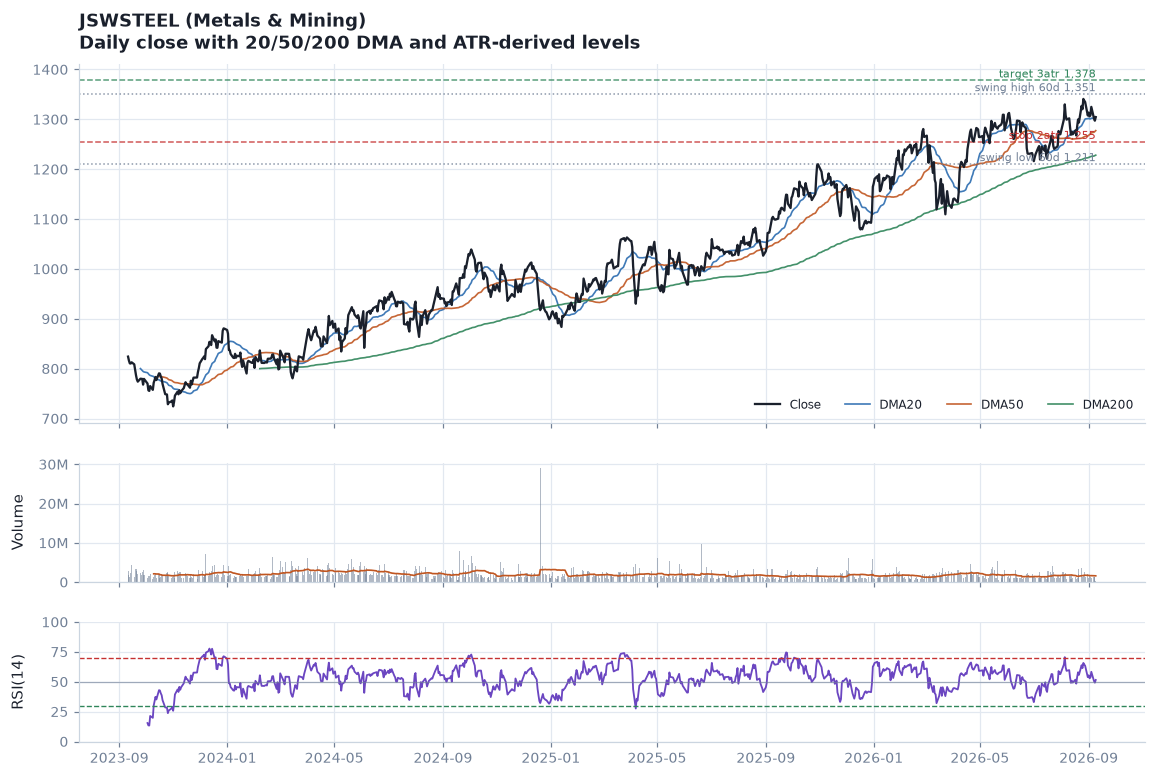

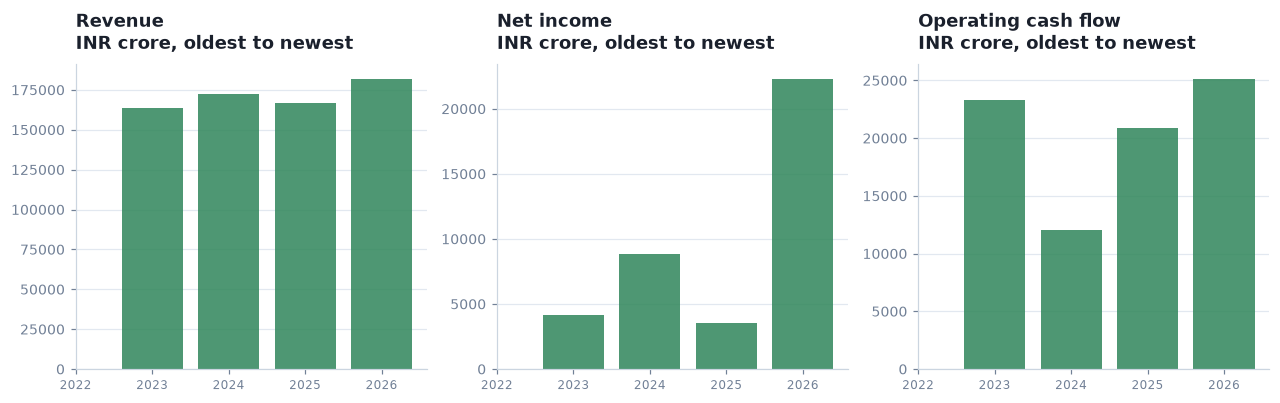


TITAN  |  Consumer Durables  |  rank 7 of 50  |  composite 77.0
   fundamental percentile 56 (coverage 100%)   technical percentile 98 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,37.13,29.17,computed,7.96
ROCE_%,73.82,50.20,computed,23.62
op_margin_%,9.14,13.29,computed,-4.15
net_margin_%,5.81,8.99,computed,-3.18
revenue_cagr_%,29.24,15.17,computed,14.07
earnings_cagr_%,16.00,8.87,computed,7.13
rev_yoy_q_%,49.58,33.74,computed,15.84
earn_yoy_q_%,104.02,71.99,computed,32.03
debt_to_equity,1.95,1.07,computed,0.88
interest_coverage,6.76,19.24,computed,-12.48


,value
last_close,"4,991.00"
RSI14,49.13
ATR14_%,1.60
px_vs_DMA20_%,-1.59
px_vs_DMA50_%,2.61
px_vs_DMA200_%,15.22
n_dma_above,2
stack_bullish,False
pos_52w_%,90.33
ret_3m_%,23.48


,level,% from close,ATR multiples
60d swing high,"5,186.70",3.92,2.46
+2 ATR,"5,150.31",3.19,2.00
+1 ATR,"5,070.66",1.60,1.00
close,"4,991.00",0.00,0.00
-1 ATR,"4,911.34",-1.60,-1.00
-2 ATR (stop),"4,831.69",-3.19,-2.00
60d swing low,"4,225.00",-15.35,-9.62
+3 ATR (target),"5,229.97",4.79,3.00


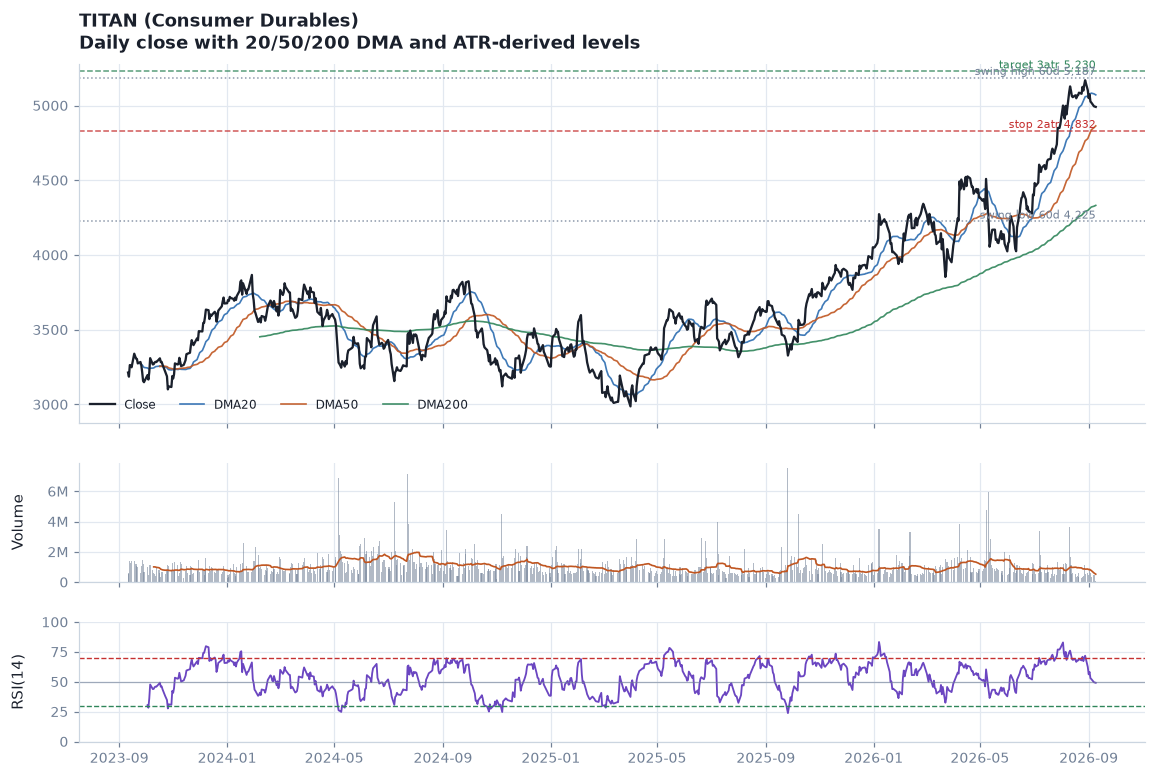

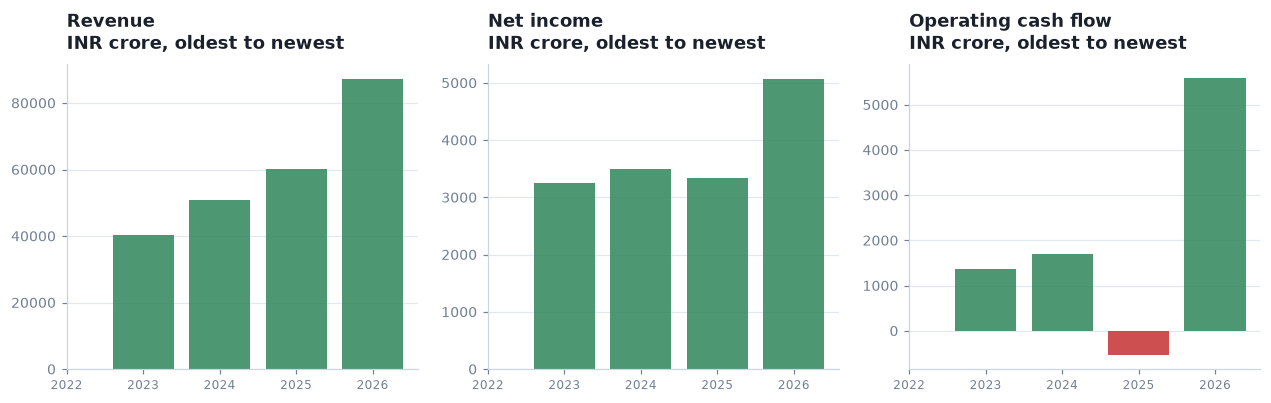


EICHERMOT  |  Automobile  |  rank 8 of 50  |  composite 76.0
   fundamental percentile 88 (coverage 100%)   technical percentile 64 (coverage 100%)


,value,sector median,provenance,vs sector
ROE_%,23.77,25.93,computed,-2.16
ROCE_%,29.11,24.07,computed,5.04
op_margin_%,31.22,16.93,computed,14.29
net_margin_%,24.00,15.00,computed,9.00
revenue_cagr_%,17.47,16.68,computed,0.79
earnings_cagr_%,23.70,22.40,computed,1.29
rev_yoy_q_%,31.20,33.07,computed,-1.87
earn_yoy_q_%,21.35,4.74,computed,16.61
debt_to_equity,0.02,0.31,computed,-0.29
interest_coverage,100.29,47.02,computed,53.27


,value
last_close,"7,694.00"
RSI14,39.36
ATR14_%,1.91
px_vs_DMA20_%,-3.39
px_vs_DMA50_%,-0.72
px_vs_DMA200_%,4.14
n_dma_above,1
stack_bullish,False
pos_52w_%,69.18
ret_3m_%,6.57


,level,% from close,ATR multiples
60d swing high,"8,165.00",6.12,3.21
+2 ATR,"7,987.23",3.81,2.00
+1 ATR,"7,840.61",1.91,1.00
close,"7,694.00",0.00,0.00
-1 ATR,"7,547.39",-1.91,-1.00
-2 ATR (stop),"7,400.77",-3.81,-2.00
60d swing low,"6,942.50",-9.77,-5.13
+3 ATR (target),"8,133.84",5.72,3.00


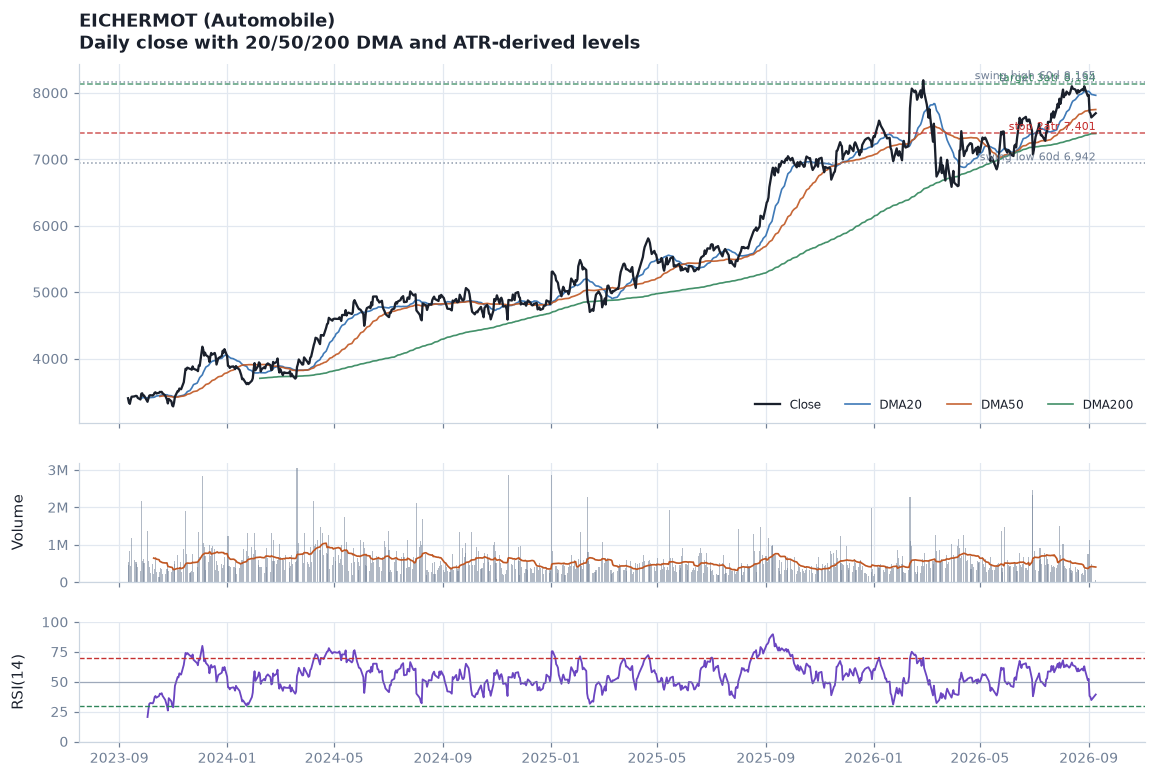

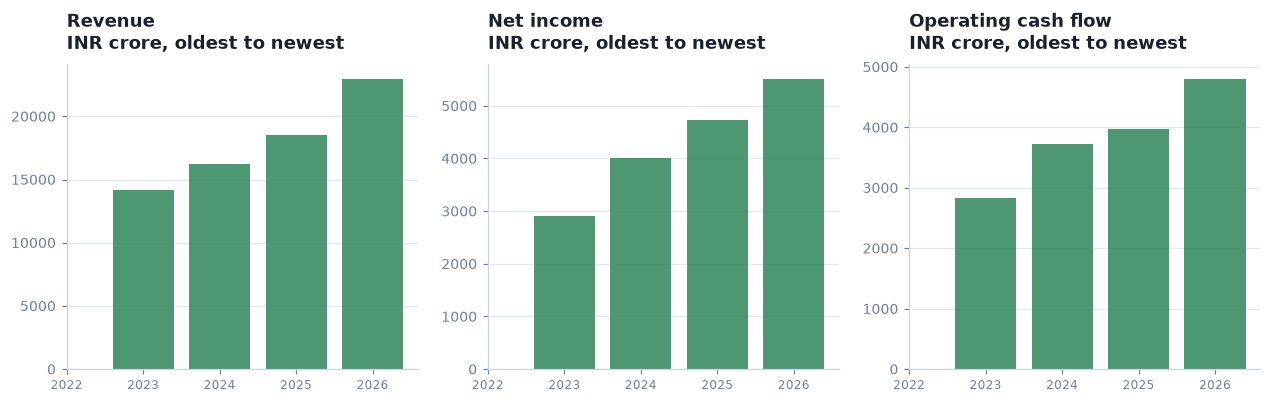

In [11]:
def deep_dive(ticker):
    df = px_frames[ticker]
    b = bundles[ticker]
    row = board.loc[ticker]
    sector = universe[ticker]
    name = ticker.replace(".NS", "")

    print("=" * 92)
    print(f"{name}  |  {sector}  |  rank {int(row['rank'])} of {len(board)}  "
          f"|  composite {row['composite']:.1f}")
    print(f"   fundamental percentile {row['fund_pct']:.0f} "
          f"(coverage {row['fund_coverage_%']:.0f}%)   "
          f"technical percentile {row['tech_pct']:.0f} "
          f"(coverage {row['tech_coverage_%']:.0f}%)")
    flags = fund.loc[ticker, "data_flags"]
    if isinstance(flags, str) and flags:
        print(f"   data note: {flags}")

    fcols = ["ROE_%", "ROCE_%", "op_margin_%", "net_margin_%", "revenue_cagr_%",
             "earnings_cagr_%", "rev_yoy_q_%", "earn_yoy_q_%", "debt_to_equity",
             "interest_coverage", "fcf_margin_%", "cash_conversion",
             "PE", "PB", "EV_EBITDA", "PEG", "div_yield_%"]
    fr = pd.DataFrame({
        "value": [pd.to_numeric(fund.loc[ticker, c], errors="coerce") for c in fcols],
        "sector median": [pd.to_numeric(fund[fund["sector"] == sector][c],
                                        errors="coerce").median() for c in fcols],
        "provenance": [provs[ticker].get(c, "") for c in fcols],
    }, index=fcols)
    fr["vs sector"] = fr["value"] - fr["sector median"]
    display(fr.round(2))

    tcols = ["last_close", "RSI14", "ATR14_%", "px_vs_DMA20_%", "px_vs_DMA50_%",
             "px_vs_DMA200_%", "n_dma_above", "stack_bullish", "pos_52w_%",
             "ret_3m_%", "ret_6m_%", "ret_12m_%", "rs_63d_pp", "rs_126d_pp",
             "vol_ann_%", "dd_from_high_%", "vol_trend_%"]
    display(tech.loc[[ticker], [c for c in tcols if c in tech.columns]].T
            .rename(columns={ticker: "value"}).round(2))

    levels = ind.atr_levels(df)
    lv = pd.DataFrame({
        "level": [levels.get(k) for k in
                  ["swing_high_60d", "resistance_2atr", "resistance_1atr", "close",
                   "support_1atr", "support_2atr", "swing_low_60d", "target_3atr"]],
    }, index=["60d swing high", "+2 ATR", "+1 ATR", "close", "-1 ATR", "-2 ATR (stop)",
              "60d swing low", "+3 ATR (target)"])
    lv["% from close"] = (lv["level"] / levels["close"] - 1) * 100
    lv["ATR multiples"] = (lv["level"] - levels["close"]) / levels["ATR"]
    display(lv.round(2))

    fig, axes = viz.price_panel(df, f"{name} ({sector})",
                                rsi_s=ind.rsi(df["Close"]), levels=levels)
    viz.save(fig, f"06_{name}_price"); plt.show()

    trends = fnd.statement_trends(b)
    if not trends.empty and len(trends) > 1:
        fig2, axs = plt.subplots(1, 3, figsize=(14, 3.6))
        scale = 1e7          # INR crore
        for axi, col, lab in zip(axs, ["revenue", "net_income", "ocf"],
                                 ["Revenue", "Net income", "Operating cash flow"]):
            if col not in trends.columns:
                axi.axis("off"); continue
            vals = trends[col] / scale
            axi.bar(range(len(vals)), vals.values,
                    color=[viz.POS if v >= 0 else viz.NEG for v in vals.values], alpha=0.85)
            axi.set_xticks(range(len(vals)))
            axi.set_xticklabels([str(i)[:4] for i in trends.index], fontsize=8)
            viz.title(axi, lab, "INR crore, oldest to newest")
            axi.grid(axis="x", visible=False)
        viz.save(fig2, f"06_{name}_statements"); plt.show()
    else:
        print("   (statement history too short to chart)")
    print()

for ticker in top.index:
    deep_dive(ticker)

## 8. The chain, end to end

In [12]:
top_payload = {}
for t in top.index:
    lv = ind.atr_levels(px_frames[t])
    top_payload[t] = {
        "rank": int(top.loc[t, "rank"]),
        "sector": universe[t],
        "composite": round(float(top.loc[t, "composite"]), 1),
        "fund_pct": round(float(top.loc[t, "fund_pct"]), 1),
        "tech_pct": round(float(top.loc[t, "tech_pct"]), 1),
        "close": round(float(lv["close"]), 2),
        "ATR14": round(float(lv["ATR"]), 2),
        "ATR_%": round(float(lv["ATR_%"]), 2),
        "stop_2atr": round(float(lv["stop_2atr"]), 2),
        "target_3atr": round(float(lv["target_3atr"]), 2),
        "swing_high_60d": round(float(lv["swing_high_60d"]), 2),
        "swing_low_60d": round(float(lv["swing_low_60d"]), 2),
        "RSI14": round(float(tech.loc[t, "RSI14"]), 1),
        "px_vs_DMA200_%": round(float(tech.loc[t, "px_vs_DMA200_%"]), 2),
        "PE": (None if not np.isfinite(pd.to_numeric(fund.loc[t, "PE"], errors="coerce"))
               else round(float(fund.loc[t, "PE"]), 2)),
        "ROE_%": (None if not np.isfinite(pd.to_numeric(fund.loc[t, "ROE_%"], errors="coerce"))
                  else round(float(fund.loc[t, "ROE_%"]), 2)),
    }

payload = {
    "signal": f"Top {len(top)} of {len(board)} screened, {top['sector'].nunique()} sectors",
    "score": round(float(top["composite"].mean()), 2),
    "as_of": str(max(tech["as_of"])),
    "weighting": config.SCORE_WEIGHTS,
    "universe_configured": len(universe),
    "universe_scored": len(board),
    "dropped": dropped,
    "top": top_payload,
    "provenance_computed_%": round(float(computed_share), 1),
    "exports": ["outputs/nifty50_screen.csv"] + (["outputs/nifty50_dropped.csv"] if dropped else []),
}
dashboard.append("06_india_companies", payload)

print("THE CHAIN\n")
display(dashboard.summary())

THE CHAIN



,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 04:42:58
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 04:49:04
8,09_positioning,"12 names scored, 6 short candidates checked fo...",54.69,2026-09-09,2026-09-09 05:12:38
9,10_portfolio,"6L / 5S, gross 1.01x, net -0.13x",7.25,2026-09-09,2026-09-09 05:01:54


In [13]:
data = dashboard.read()
print("=" * 92)
print("MACRO -> RISK -> RATES -> GLOBAL EQUITY -> INDIA -> COMPANIES")
print("=" * 92)
for key, label in [("01_macro", "Economic state"), ("02_risk", "Global risk"),
                   ("03_rates", "Rates / duration"), ("04_global_equity", "Global equity"),
                   ("05_india_market", "India market"), ("06_india_companies", "Companies")]:
    blk = data.get(key)
    if not blk:
        print(f"{label:18s} : (notebook not run yet)")
        continue
    sc = blk.get("score")
    print(f"{label:18s} : {str(blk.get('signal',''))[:62]:64s}"
          f"{'' if sc is None else f'score {sc:+.2f}'}   as of {blk.get('as_of','')}")
print("=" * 92)
print(f"\nTop {len(top)} names:")
for t, d in top_payload.items():
    print(f"  {d['rank']}. {t.replace('.NS',''):14s} {d['sector']:22s} "
          f"composite {d['composite']:5.1f}  (F {d['fund_pct']:3.0f} / T {d['tech_pct']:3.0f})  "
          f"close {d['close']:>9,.2f}  ATR {d['ATR_%']:.1f}%")

MACRO -> RISK -> RATES -> GLOBAL EQUITY -> INDIA -> COMPANIES
Economic state     : Goldilocks (growth, cooling prices) | nowcast: Mixed            score +0.00   as of 2026-09-09
Global risk        : Neutral                                                         score -0.10   as of 2026-09-08
Rates / duration   : Cautious on duration                                            score -0.27   as of 2026-09-08
Global equity      : India lagging the world                                         score -39.12   as of 2026-09-09
India market       : Mixed                                                           score +0.23   as of 2026-09-09 10:41:00
Companies          : Top 8 of 50 screened, 6 sectors                                 score +80.75   as of 2026-09-09

Top 8 names:
  1. BAJAJ-AUTO     Automobile             composite  89.0  (F  82 / T  96)  close 11,858.00  ATR 1.8%
  2. KOTAKBANK      Financial Services     composite  84.0  (F  80 / T  88)  close    414.85  ATR 1.7%
  3. COALIN

## Re-running this project

Every notebook re-derives its conclusions from freshly fetched data. Nothing here is a
static snapshot.

- **Normal re-run:** execute the notebooks in order. Cached sources are reused inside
  their TTL (prices 12h, fundamentals 1 week, NSE 6h).
- **Force fresh data:** set `REFRESH = True` in the first cell of any notebook.
- **Cold start:** delete `data/cache/` and re-run. The FII/DII history in
  `data/fii_dii_history.csv` is deliberately *not* part of the cache — it is accumulated
  state and deleting it loses the flow series.

The composite scores, sector ranks and ATR levels will all move as the data moves. That
is the point: these are analytical tools you re-run, not a report you read once. The
decisions are yours.